<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reservoir Analysis: Is Rainfall Sufficient to Explain Dam Levels?

This notebook analyzes whether rainfall alone is sufficient to explain reservoir levels in Istanbul. The analysis uses:
- official dam occupancy data
- historical weather data from Open-Meteo

The workflow includes:
1. data cleaning
2. monthly aggregation
3. exploratory data analysis
4. correlation analysis
5. regression models
6. lag analysis


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr

In [12]:
dam = pd.read_csv("dam_occupancy.csv")
weather = pd.read_csv("open-meteo-41.02N29.02E48m (1).csv", skiprows=2)

In [13]:
print("DAM DATA")
display(dam.head())

print("WEATHER DATA")
display(weather.head())

DAM DATA


,DATE,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER
0,2005-01-01,44.62,388
1,2005-01-02,44.62,388
2,2005-01-03,44.47,386
3,2005-01-04,44.42,386
4,2005-01-05,44.35,385


WEATHER DATA


,time,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm)
0,2000-01-27,0.0,-3.0,0.0
1,2000-01-28,0.0,1.6,0.0
2,2000-01-29,0.0,2.2,0.0
3,2000-01-30,0.0,6.7,0.0
4,2000-01-31,0.0,8.0,0.0


In [14]:
dam["DATE"] = pd.to_datetime(dam["DATE"])
dam = dam.set_index("DATE")

dam = dam.rename(columns={
    "GENERAL_DAM_OCCUPANCY_RATE": "dam",
    "GENERAL_DAM_RESERVED_WATER": "water"
})

display(dam.head())
print(dam.info())

,dam,water
DATE,,
2005-01-01,44.62,388
2005-01-02,44.62,388
2005-01-03,44.47,386
2005-01-04,44.42,386
2005-01-05,44.35,385


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5941 entries, 2005-01-01 to 2021-04-07
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dam     5941 non-null   float64
 1   water   5941 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 139.2 KB
None


In [15]:
weather["time"] = pd.to_datetime(weather["time"])
weather = weather.set_index("time")

weather = weather.rename(columns={
    "precipitation_sum (mm)": "precip",
    "temperature_2m_mean (°C)": "temp",
    "rain_sum (mm)": "rain"
})

display(weather.head())
print(weather.info())

,precip,temp,rain
time,,,
2000-01-27,0.0,-3.0,0.0
2000-01-28,0.0,1.6,0.0
2000-01-29,0.0,2.2,0.0
2000-01-30,0.0,6.7,0.0
2000-01-31,0.0,8.0,0.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9571 entries, 2000-01-27 to 2026-04-10
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   precip  9571 non-null   float64
 1   temp    9571 non-null   float64
 2   rain    9571 non-null   float64
dtypes: float64(3)
memory usage: 299.1 KB
None


In [16]:
print("Missing values in dam data:")
print(dam.isna().sum())

print("\nMissing values in weather data:")
print(weather.isna().sum())

Missing values in dam data:
dam      0
water    0
dtype: int64

Missing values in weather data:
precip    0
temp      0
rain      0
dtype: int64


In [17]:
dam_monthly = dam.resample("ME").mean()

weather_monthly = weather.resample("ME").agg({
    "precip": "sum",
    "rain": "sum",
    "temp": "mean"
})

print("DAM MONTHLY")
display(dam_monthly.head())

print("WEATHER MONTHLY")
display(weather_monthly.head())

DAM MONTHLY


,dam,water
DATE,,
2005-01-31,46.650000,405.258065
2005-02-28,72.679286,631.285714
2005-03-31,92.837097,806.419355
2005-04-30,92.331667,802.100000
2005-05-31,87.719677,762.032258


WEATHER MONTHLY


,precip,rain,temp
time,,,
2000-01-31,0.0,0.0,3.100000
2000-02-29,65.2,65.0,5.962069
2000-03-31,85.1,69.9,7.283871
2000-04-30,84.5,84.5,13.186667
2000-05-31,68.9,68.9,15.803226


In [18]:
df = dam_monthly.merge(weather_monthly, left_index=True, right_index=True, how="inner")

print("MERGED DATA")
display(df.head())
print(df.info())

MERGED DATA


,dam,water,precip,rain,temp
2005-01-31,46.650000,405.258065,126.2,125.6,7.006452
2005-02-28,72.679286,631.285714,108.5,87.7,5.996429
2005-03-31,92.837097,806.419355,66.8,56.7,7.090323
2005-04-30,92.331667,802.100000,36.1,36.1,11.813333
2005-05-31,87.719677,762.032258,12.3,12.3,16.148387


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 196 entries, 2005-01-31 to 2021-04-30
Freq: ME
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dam     196 non-null    float64
 1   water   196 non-null    float64
 2   precip  196 non-null    float64
 3   rain    196 non-null    float64
 4   temp    196 non-null    float64
dtypes: float64(5)
memory usage: 9.2 KB
None


In [19]:
display(df.describe())

,dam,water,precip,rain,temp
count,196.000000,196.000000,196.000000,196.000000,196.000000
mean,64.861690,563.397437,57.812755,54.771939,14.871435
std,23.217389,201.703248,41.618465,39.166955,6.764106
min,12.230968,106.387097,0.800000,0.800000,2.767742
25%,48.431214,420.601786,26.300000,25.425000,8.441935
50%,67.276613,584.483871,51.550000,50.000000,14.537097
75%,85.827857,745.587500,81.025000,78.800000,21.352500
max,98.714839,857.580645,252.400000,252.400000,26.545161


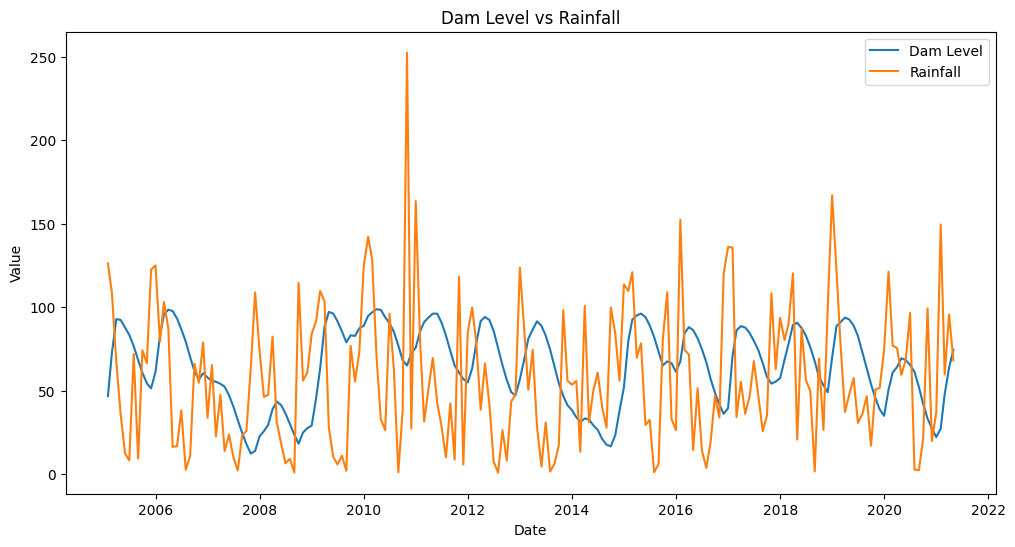

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["dam"], label="Dam Level")
plt.plot(df.index, df["precip"], label="Rainfall")
plt.title("Dam Level vs Rainfall")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

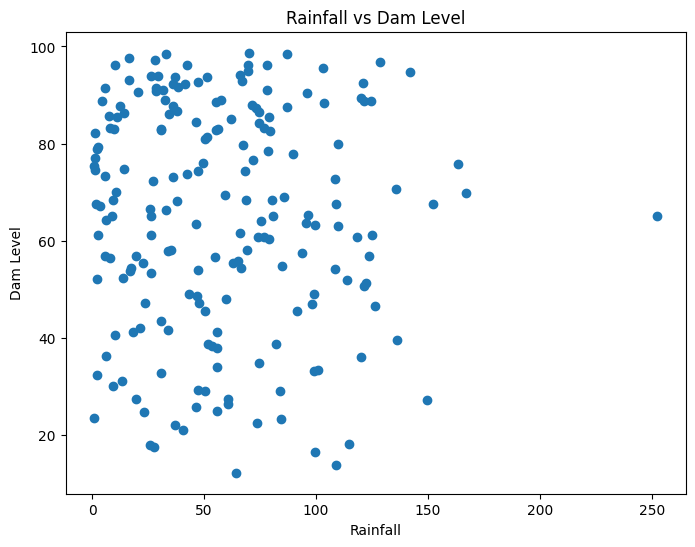

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df["precip"], df["dam"])
plt.title("Rainfall vs Dam Level")
plt.xlabel("Rainfall")
plt.ylabel("Dam Level")
plt.show()

In [22]:
corr_matrix = df[["dam", "water", "precip", "rain", "temp"]].corr()
display(corr_matrix)

,dam,water,precip,rain,temp
dam,1.000000,1.000000,-0.039229,-0.064438,-0.073179
water,1.000000,1.000000,-0.039217,-0.064426,-0.073170
precip,-0.039229,-0.039217,1.000000,0.980721,-0.554252
rain,-0.064438,-0.064426,0.980721,1.000000,-0.487371
temp,-0.073179,-0.073170,-0.554252,-0.487371,1.000000


In [23]:
corr, p_value = pearsonr(df["precip"], df["dam"])

print("Pearson Correlation:", corr)
print("P-value:", p_value)

Pearson Correlation: -0.03922919964181322
P-value: 0.5851305052748212


In [24]:
X = df[["precip"]]
X = sm.add_constant(X)
y = df["dam"]

model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    dam   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.2990
Date:                Sun, 12 Apr 2026   Prob (F-statistic):              0.585
Time:                        16:02:39   Log-Likelihood:                -893.86
No. Observations:                 196   AIC:                             1792.
Df Residuals:                     194   BIC:                             1798.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.1269      2.848     23.215      0.0

In [25]:
X2 = df[["precip", "temp"]]
X2 = sm.add_constant(X2)
y = df["dam"]

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    dam   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.424
Date:                Sun, 12 Apr 2026   Prob (F-statistic):              0.243
Time:                        16:02:42   Log-Likelihood:                -892.58
No. Observations:                 196   AIC:                             1791.
Df Residuals:                     193   BIC:                             1801.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.5698      6.562     11.517      0.0

In [26]:
df["precip_lag1"] = df["precip"].shift(1)
df["precip_lag2"] = df["precip"].shift(2)
df["precip_lag3"] = df["precip"].shift(3)

df_lag = df.dropna().copy()

display(df_lag.head())

,dam,water,precip,rain,temp,precip_lag1,precip_lag2,precip_lag3
2005-04-30,92.331667,802.100000,36.1,36.1,11.813333,66.8,108.5,126.2
2005-05-31,87.719677,762.032258,12.3,12.3,16.148387,36.1,66.8,108.5
2005-06-30,83.309333,723.666667,8.2,8.2,20.243333,12.3,36.1,66.8
2005-07-31,76.624516,665.741935,71.9,71.9,23.506452,8.2,12.3,36.1
2005-08-31,68.293871,593.129032,9.3,9.3,24.680645,71.9,8.2,12.3


In [27]:
lag_corr = df_lag[["dam", "precip", "precip_lag1", "precip_lag2", "precip_lag3"]].corr()
display(lag_corr)

,dam,precip,precip_lag1,precip_lag2,precip_lag3
dam,1.000000,-0.036728,0.204458,0.355627,0.441412
precip,-0.036728,1.000000,0.272981,0.174263,0.025331
precip_lag1,0.204458,0.272981,1.000000,0.272741,0.174960
precip_lag2,0.355627,0.174263,0.272741,1.000000,0.280664
precip_lag3,0.441412,0.025331,0.174960,0.280664,1.000000


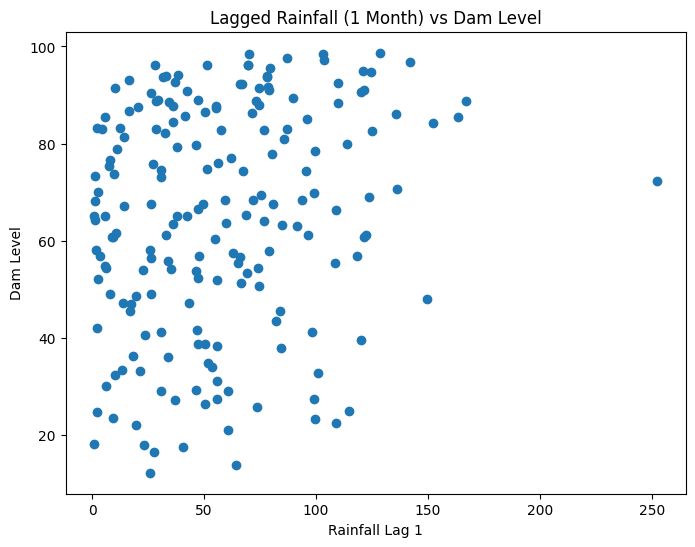

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(df_lag["precip_lag1"], df_lag["dam"])
plt.title("Lagged Rainfall (1 Month) vs Dam Level")
plt.xlabel("Rainfall Lag 1")
plt.ylabel("Dam Level")
plt.show()

In [29]:
X_lag = df_lag[["precip_lag1", "precip_lag2", "precip_lag3"]]
X_lag = sm.add_constant(X_lag)
y_lag = df_lag["dam"]

model_lag = sm.OLS(y_lag, X_lag).fit()
print(model_lag.summary())

                            OLS Regression Results                            
Dep. Variable:                    dam   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     21.98
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.97e-12
Time:                        16:02:52   Log-Likelihood:                -851.85
No. Observations:                 193   AIC:                             1712.
Df Residuals:                     189   BIC:                             1725.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          43.2282      3.203     13.498      

In [30]:
print("FINAL RESULTS")
print("-" * 50)
print(f"Pearson correlation between rainfall and dam level: {corr:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Model 1 R-squared: {model1.rsquared:.4f}")
print(f"Model 2 R-squared: {model2.rsquared:.4f}")
print(f"Lag model R-squared: {model_lag.rsquared:.4f}")

FINAL RESULTS
--------------------------------------------------
Pearson correlation between rainfall and dam level: -0.0392
P-value: 0.5851
Model 1 R-squared: 0.0015
Model 2 R-squared: 0.0145
Lag model R-squared: 0.2586
